# AI/ML Internship Task 2
## Feature Engineering, Model Optimization & Performance Comparison

### Objective
To improve the House Price Prediction model using feature scaling and compare multiple regression algorithms.

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## Dataset Loading
Loading the California Housing Dataset from Scikit-Learn.

In [2]:
# Load Dataset

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
# Check Missing Values

df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

## Feature Selection
Separating input features and target variable.

In [5]:
# Features and Target

X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

## Feature Scaling
Standardizing numerical features using StandardScaler.

In [6]:
# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (16512, 8)
Testing Shape: (4128, 8)


## Model Training
Training multiple regression models for comparison.

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

In [10]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

In [11]:
results_df = pd.DataFrame(results).T

results_df

,RMSE,R2 Score
Linear Regression,0.745581,0.575788
Ridge Regression,0.745554,0.575819
Decision Tree,0.724234,0.599732


## Model Comparison Visualization
Comparing model performance graphically.

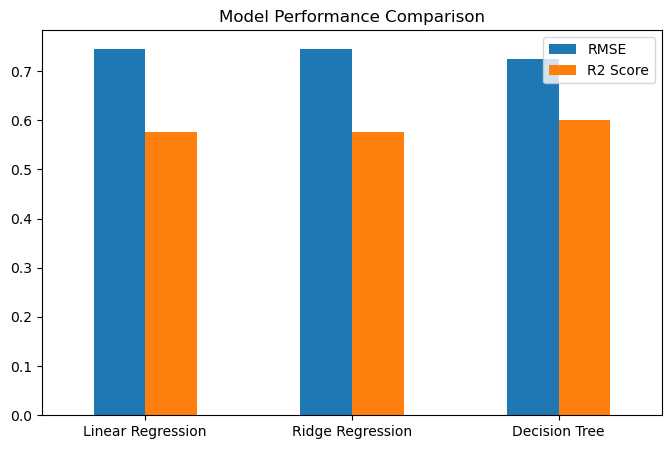

In [12]:
results_df.plot(kind="bar", figsize=(8,5))

plt.title("Model Performance Comparison")

plt.xticks(rotation=0)

plt.show()

In [13]:
best_model = LinearRegression()

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

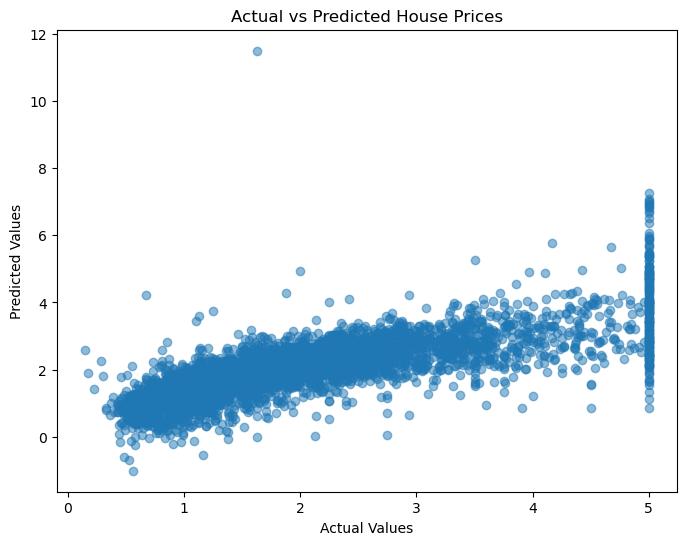

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [15]:
import joblib

joblib.dump(best_model, "best_house_price_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully
